# PIDNet

PIDNet es una arquitectura para segmetación semántica en tiempo real que emplea el concepto básico de un controlado PID (Proportional-Integral-Derivative). Muchos modelos con gran balance de exactitud y velocidad adecuados para segmentación en tiempo real (BiSeNet, Fast-SCNN, DDRNet, etc) son tipo TBN (Two-Branch-Network). Al analizar esta estrategia desde la perspectiva de un controlador PID, se puede hacer una equivalencia de dicha arquitectura con un controlador PI, el cuál suele tener problemas de sobrepaso (overshoot). A nivel imagen, esto puede traducirse en una rama que aprovecha la información semántica original (P) y otra rama que almacena información contextual de baja frecuencia (I), tal que un modelo de segmentación que usa la fusión de ambas conlleva el riesgo de que los límites de los objetos se vean excesivamente erosionados por los pixeles circundantes y que los objetos pequeños quede eclipsados por los objetos grandes adyacentes.

Para mitigar eso, se propone adjuntar una tercera rama "derivativa". La rama derivativa de un controlador PID se enfoca en la velocidad de cambio de una señal, permitiendo una mejor sensibilidad a cambios de alta frecuencia. En una imagen, esto representa un mejor enfoque sobre los bordes de los objetos o regiones. Dado que las grietas suelen tener una elevada relación perímetro-área, una red cuya detección de bordes está mejorada, en teoría resulta ideal para una aplicación de segmentación de grietas.

La red propuesta, además utiliza los siguientes módulos específicos para que las ramas interactúen de forma inteligente:
- Pag (Pixel-attention-guided fusion): Este módulo permite que la rama de detalles (P) aprenda selectivamente características semánticas ricas de la rama de contexto (I) sin ser abrumada por ella. Utiliza un mecanismo de atención por píxel para decidir cuánta confianza otorgar a la información de contexto en cada punto.
- PAPPM (Parallel Aggregation Pyramid Pooling Module): Es una versión optimizada del módulo PPM tradicional. En lugar de procesar las escalas de forma secuencial, lo hace de forma paralela para reducir la latencia y mantener la velocidad necesaria en aplicaciones de tiempo real.
- Bag (Boundary-attention-guided fusion): Es el corazón de la integración PID. Utiliza las fronteras detectadas por la rama D para guiar la fusión entre la rama de detalles (P) y la de contexto (I). Básicamente, "obliga" a la red a confiar más en la rama de detalles cuando está cerca de un borde y en la de contexto cuando está dentro de un objeto.

La función de pérdida de la red resulta más compleja. Se compone una suma ponderada de 4 pérdidas que balancean el aprendizaje de bordes y semántica.

$$ Loss = \lambda_0l_0 + \lambda_1l_1 + \lambda_2l_2 + \lambda_3l_3$$
1. $l0$: Pérdida semántica auxiliar para optimizar toda la red
2. $l1$: Pérdida de entropía cruzada binaria ponderada para la detección de bordes (rama D)
3. $l2$: Pérdida de entropía cruzada estándar para la segmentación final
4. $l3$: Pérdida de entropía cruzada con conciencia de frontera (boundary-awareness), que coordina las tareas de segmentación y detección de bordes

**Adaptación para rama derivativa**: La rama derivativa requiere una supervisión directa mediante mapas de bordes reales para entrenarse correctamente. Dado que el dataset de DeepCrack proporciona únicamente las máscaras binarias grieta/fondo, es necesario generar también las etiquetas de borde. Para ello, se propone generarlas usando un detector de bordes de Canny durante la misma carga del dataset (on-the-fly).

In [2]:
# ==== Solo para ejecutar en Colab ========
try:
    from google.colab import drive
    import os
    import sys

    # 1. Montar Google Drive
    drive.mount('/content/drive')

    # 2. Definir la ruta a tu proyecto dentro de Drive
    # (Asegúrate de ajustar esta ruta si guardaste la carpeta en otro lado dentro de tu Drive)
    project_path = '/content/drive/MyDrive/tp_computer_vision_ii'
    notebook_dir = os.path.join(project_path, 'src', 'pidnet')

    # 3. Movernos al directorio donde está el notebook para que las rutas relativas funcionen
    os.chdir(notebook_dir)

    # 4. Agregar la ruta a sys.path para que Python encuentre la carpeta "models"
    if notebook_dir not in sys.path:
        sys.path.append(notebook_dir)

    print("Directorio actual:", os.getcwd())
    IN_COLAB = True

except:
    IN_COLAB = False

In [3]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import random
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR

from models.pidnet import PIDNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [40]:
class JointTransform:
    """
    Aplica las mismas transformaciones geométricas a las imágenes y las máscaras.

    Los bordes deben generarse (con Canny) después de aplicar las transformaciones
    sobre la máscara.
    """
    def __init__(
        self, 
        scale_limit=(0.5, 2.0),
        crop_size=(512, 512),
        hflip_p=0.5,
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ):
        self.scale_limit = scale_limit
        self.crop_h, self.crop_w = crop_size
        self.hflip_p = hflip_p
        self.mean = np.array(mean, dtype=np.float32)
        self.std = np.array(std, dtype=np.float32)

    def __call__(self, image, mask):
        # image: HxWx3 uint8 RGB ; mask: HxW uint8 (0/1)
        
        # Random Scale
        scale = random.uniform(*self.scale_limit)
        h, w = image.shape[:2]
        new_h, new_w = max(1, int(h * scale)), max(1, int(w * scale))
        image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

        # Padding (Si queda más chica que el crop)
        pad_h = max(self.crop_h - new_h, 0)
        pad_w = max(self.crop_w - new_w, 0)
        if pad_h > 0 or pad_w > 0:
            image = cv2.copyMakeBorder(image, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=0)
            mask = cv2.copyMakeBorder(mask, 0, pad_h, 0, pad_w, cv2.BORDER_CONSTANT, value=0)

        # Random crop
        h, w = image.shape[:2]
        top = random.randint(0, h - self.crop_h)
        left = random.randint(0, w - self.crop_w)
        image = image[top:top + self.crop_h, left:left + self.crop_w]
        mask = mask[top:top + self.crop_h, left:left + self.crop_w]

        # Horizontal flip
        if random.random() < self.hflip_p:
            image = cv2.flip(image, 1)
            mask = cv2.flip(mask, 1)

        return image, mask

    def normalize_and_to_tensor(self, image):
        image = image.astype(np.float32) / 255.0
        image = (image - self.mean) / self.std
        return torch.from_numpy(image).permute(2, 0, 1).float()


In [ ]:
class ValTransform:
    """
    Transformación para validación: redimensionado determinista y normalización ImageNet.
    """
    def __init__(self, target_size=(512, 512), mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
        self.target_size = target_size
        self.mean = np.array(mean, dtype=np.float32)
        self.std  = np.array(std,  dtype=np.float32)

    def __call__(self, image, mask):
        # image: HxWx3 uint8 RGB ; mask: HxW uint8 (0/1)
        if self.target_size is not None:
            image = cv2.resize(image, (self.target_size[1], self.target_size[0]), interpolation=cv2.INTER_LINEAR)
            mask = cv2.resize(mask, (self.target_size[1], self.target_size[0]), interpolation=cv2.INTER_NEAREST)
        return image, mask

    def normalize_and_to_tensor(self, image):
        image = image.astype(np.float32) / 255.0
        image = (image - self.mean) / self.std
        return torch.from_numpy(image).permute(2, 0, 1).float()


In [52]:
class DeepCrackDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        """
        split: 'train' o 'test'
        """
        self.root_dir = root_dir
        self.img_dir = os.path.join(self.root_dir, f"{split}_img")
        self.lab_dir = os.path.join(self.root_dir, f"{split}_lab")
        self.images = sorted(os.listdir(self.img_dir))
        self.transform = transform      # Usar JointTransform
        self.mean = np.array((0.485, 0.456, 0.406), dtype=np.float32)
        self.std = np.array((0.229, 0.224, 0.225), dtype=np.float32)

    def __len__(self):
        return len(self.images)

    def _generate_boundary_on_the_fly(self, mask):
        # Habría que jugar un poco con los parámetros de OpenCV para optimizar resultados,
        # pero probablemente lo mejor sería un tratamiento por imagen individual
        # Aplicar Canny para detectar los bordes
        edges = cv2.Canny(mask, 10, 100)

        # Dilatación morfológica para expandir fronteras y conpensar ruido
        kernel = np.ones((3, 3), np.uint8)
        dilated_edges = cv2.dilate(edges, kernel, iterations=1)

        # Normalizar 0-1
        return (dilated_edges > 0).astype(np.float32)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # Las máscaras tienen extensión .png, a diferencia de las imágenes
        # que son .jpg
        lab_name = os.path.splitext(img_name)[0] + '.png'
        lab_path = os.path.join(self.lab_dir, lab_name)

        # Cargar imágenes y máscara
        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(lab_path, cv2.IMREAD_GRAYSCALE)

        # Binarizar máscara
        mask = (mask > 127).astype(np.uint8)

        if self.transform:
            image, mask = self.transform(image, mask)
        else:
            # Redimensionar a un tamaño fijo para todas las imágenes del dataset
            target_size = (512, 512)
            image = cv2.resize(image, target_size, interpolation=cv2.INTER_LINEAR)
            mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)
        
        # Generar ground truth para la rama derivativa
        boundary = self._generate_boundary_on_the_fly((mask * 255).astype(np.uint8))

        if self.transform:
            image = self.transform.normalize_and_to_tensor(image)
        else:
            image = (image.astype(np.float32) / 255.0 - self.mean) / self.std
            # Convertir a tensor si no hay transformación
            image = torch.from_numpy(image).permute(2, 0, 1).float()

        mask = torch.from_numpy(mask.astype(np.int64))
        boundary = torch.from_numpy(boundary)

        return image, mask, boundary


In [53]:
def build_custom_pidnet(pretrained_path='PIDNet_M_Cityscapes_test.pt', num_classes=2, variant='S'):
    """
    Construye una PIDNet evitando usar el sistema yacs/cfg del repositorio original y carga
    los pesos pre-entrenados de Cityscapes y los adapta a num_classes.

    Debe descargarse el modelo con los pesos pre-entrenados desde
    https://drive.google.com/drive/folders/0BySIOtxxULinfld0LTcxYndTbFpWNjVpWm9nREU1T3hJUW5IS2otOUJDMmtnZERuODFPVU0?resourcekey=0-nauDQNE1efkunvcg89ZlDA
    y guardar en src\pidnet\pretrained_models, ya que se ignora en el tracking de git por el peso.
    """
    # Configuración de arquitectura siguiendo la base del paper, ya que se rellenará con los pesos pre-entrenados
    # de alguno de los modelos creados de esta manera.
    if variant == 'S':
        model = PIDNet(m=2, n=3, num_classes=num_classes, planes=32, ppm_planes=96, head_planes=128, augment=True)
    elif variant == 'M':
        model = PIDNet(m=2, n=3, num_classes=num_classes, planes=64, ppm_planes=96, head_planes=128, augment=True)
    elif variant == 'L':
        model = PIDNet(m=3, n=4, num_classes=num_classes, planes=64, ppm_planes=112, head_planes=256, augment=True)
    else:
        raise ValueError("Variante no soportada")

    # Cargar el State Dict pre-entrenado
    print(f"Cargando pesos desde {pretrained_path}...")
    pretrained_dict = torch.load(pretrained_path, map_location='cpu')

    # Manejo de diccionarios si el modelo fue guardado con DataParallel (prefijo 'module.')
    if 'state_dict' in pretrained_dict:
        pretrained_dict = pretrained_dict['state_dict']
    pretrained_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in pretrained_dict.items()}

    model_dict = model.state_dict()

    # Filtrado -> Se conservan solo los pesos cuyas keys existen y cuyas dimensiones coinciden exactamente
    filtered_dict = {
        k: v for k, v in pretrained_dict.items()
        if k in model_dict and v.shape == model_dict[k].shape
    }

    model_dict.update(filtered_dict)
    model.load_state_dict(model_dict)

    # print("Checkpoint keys:", list(pretrained_dict.keys())[:10])
    # print("Model keys:", list(model_dict.keys())[:10])

    # Verificación y diagnóstico
    omitidas = set(pretrained_dict.keys()) - set(filtered_dict.keys())
    print(f"\n--- Diagnóstico de Carga ---")
    print(f"Capas pre-entrenadas cargadas con éxito: {len(filtered_dict)}")
    print(f"Capas omitidas (reinicializadas aleatoriamente para {num_classes} clases): {len(omitidas)}")
    for k in sorted(omitidas):
        print(f" -> {k} (Forma original: {pretrained_dict[k].shape})")

    return model


<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_15448\2796371034.py:8: SyntaxWarning: invalid escape sequence '\p'
  y guardar en src\pidnet\pretrained_models, ya que se ignora en el tracking de git por el peso.


In [54]:
def build_custom_pidnet_v2(pretrained_path='PIDNet_M_Cityscapes_test.pt', num_classes=2, variant='S'):
    """
    Construye una PIDNet evitando usar el sistema yacs/cfg del repositorio original y carga
    los pesos pre-entrenados de Cityscapes y los adapta a num_classes.

    Debe descargarse el modelo con los pesos pre-entrenados desde
    https://drive.google.com/drive/folders/0BySIOtxxULinfld0LTcxYndTbFpWNjVpWm9nREU1T3hJUW5IS2otOUJDMmtnZERuODFPVU0?resourcekey=0-nauDQNE1efkunvcg89ZlDA
    y guardar en src\pidnet\pretrained_models, ya que se ignora en el tracking de git por el peso.
    """
    # Configuración de arquitectura siguiendo la base del paper, ya que se rellenará con los pesos pre-entrenados
    # de alguno de los modelos creados de esta manera.
    if variant == 'S':
        model = PIDNet(m=2, n=3, num_classes=num_classes, planes=32, ppm_planes=96, head_planes=128, augment=True)
    elif variant == 'M':
        model = PIDNet(m=2, n=3, num_classes=num_classes, planes=64, ppm_planes=96, head_planes=128, augment=True)
    elif variant == 'L':
        model = PIDNet(m=3, n=4, num_classes=num_classes, planes=64, ppm_planes=112, head_planes=256, augment=True)
    else:
        raise ValueError("Variante no soportada")

    # Cargar el State Dict pre-entrenado
    print(f"Cargando pesos desde {pretrained_path}...")
    pretrained_dict = torch.load(pretrained_path, map_location='cpu')

    # Manejo de diccionarios si el modelo fue guardado con DataParallel (prefijo 'module.')
    if 'state_dict' in pretrained_dict:
        pretrained_dict = pretrained_dict['state_dict']
    pretrained_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in pretrained_dict.items()}

    # Se define explícitamente qué capas reiniciar
    # Estas son las capas finales que predecían 19 clases y ahora se quiere que predigan 'num_classes' (2)
    layers_to_reset = [
        'final_layer.conv2.weight', 'final_layer.conv2.bias',
        'seghead_p.conv2.weight', 'seghead_p.conv2.bias'
    ]
    
    for layer in layers_to_reset:
        if layer in pretrained_dict:
            del pretrained_dict[layer]
            

    # CARGAR USANDO STRICT=FALSE
    # strict=False permite cargar el diccionario aunque le falten llaves (las que borramos,
    # que quedarán inicializadas al azar) o aunque tenga llaves de más (capas que no existen en tu modelo).
    missing_keys, unexpected_keys = model.load_state_dict(pretrained_dict, strict=False)
    print("\n--- Diagnóstico de Carga ---")
    print(f"Capas reinicializadas aleatoriamente para {num_classes} clases:")
    for key in missing_keys:
        print(f" -> {key}")
        
    if unexpected_keys:
        print(f"\n[ADVERTENCIA] Capas en el .pt que NO EXISTEN en el modelo instanciado ({len(unexpected_keys)} capas):")
        # Mostrar solo algunas para no llenar la pantalla
        for key in unexpected_keys[:10]:
            print(f" -> {key}")
        print(" -> ... (revisa la arquitectura, podría haber un mismatch en los parámetros m, n, etc.)")
    return model


<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_15448\4219736075.py:8: SyntaxWarning: invalid escape sequence '\p'
  y guardar en src\pidnet\pretrained_models, ya que se ignora en el tracking de git por el peso.


In [55]:
NUM_CLASSES = 2
VARIANT = "S"
pretrained_path = os.path.join('pretrained_models', 'PIDNet_S_Cityscapes_test.pt')

model = build_custom_pidnet(
    pretrained_path=pretrained_path,
    num_classes=NUM_CLASSES,
    variant=VARIANT
)

Cargando pesos desde pretrained_models\PIDNet_S_Cityscapes_test.pt...

--- Diagnóstico de Carga ---
Capas pre-entrenadas cargadas con éxito: 475
Capas omitidas (reinicializadas aleatoriamente para 2 clases): 6
 -> final_layer.conv2.bias (Forma original: torch.Size([19]))
 -> final_layer.conv2.weight (Forma original: torch.Size([19, 128, 1, 1]))
 -> sb_loss.criterion.weight (Forma original: torch.Size([19]))
 -> seghead_p.conv2.bias (Forma original: torch.Size([19]))
 -> seghead_p.conv2.weight (Forma original: torch.Size([19, 128, 1, 1]))
 -> sem_loss.criterion.weight (Forma original: torch.Size([19]))


In [56]:
model

PIDNet(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(32, 32, ke

In [ ]:
# import albumentations as A
# from albumentations.pytorch import ToTensorV2

# # Definir las transformaciones (Escalado aleatorio, Recorte y Normalización ImageNet)
# train_transform = A.Compose([
#     A.RandomScale(scale_limit=(-0.5, 1.0), p=1.0),
#     A.RandomCrop(height=512, width=512), # Ajusta al tamaño de tu GPU
#     A.HorizontalFlip(p=0.5),
#     A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
#     ToTensorV2(),
# ])

# train_transform = None

if device == 'cuda':
    num_workers = 2
else:
    num_workers = 0

train_transform = JointTransform(scale_limit=(0.5, 2.0), crop_size=(512, 512), hflip_p=0.5)
val_transform = ValTransform()

# Instanciar el Dataset (usando la clase DeepCrackDataset adaptada para albumentations)
train_dataset = DeepCrackDataset(root_dir='../../datasets/dataset_1000', split='train', transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=num_workers, drop_last=True)

val_dataset = DeepCrackDataset(root_dir='../../datasets/dataset_1000', split='test', transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=num_workers)

In [58]:
class BoundaryAwareCrossEntropy(nn.Module):
    def __init__(self, gamma=1.0):
        super(BoundaryAwareCrossEntropy, self).__init__()
        self.gamma = gamma

    def forward(self, semantic_preds, boundary_preds, targets):
        """
        semantic_preds: Probabilidades Softmax (s_head2) [B, C, H, W]
        boundary_preds: Activaciones Sigmoide (d_head) [B, 1, H, W]
        targets: Etiquetas manuales [B, H, W]
        """
        # Calcular entropía cruzada estándar sin reducción
        ce_loss = F.cross_entropy(semantic_preds, targets, reduction='none')

        # Escalar la pérdida espacialmente con las predicciones de frontera
        # (1 + gamma * p_boundary)
        boundary_weight = 1.0 + (self.gamma * boundary_preds.squeeze(1))

        # Aplicar el castigo ponderado
        weighted_ce = ce_loss * boundary_weight

        return weighted_ce.mean()

In [59]:
# 1. Definición de las funciones de pérdida
criterion_semantic = nn.CrossEntropyLoss(ignore_index=255) # l_0 y l_2
criterion_boundary = nn.BCEWithLogitsLoss()                # l_1
criterion_boundary_aware = BoundaryAwareCrossEntropy()     # l_3 (La que definimos en el paso anterior)

# 2. Optimizador (SGD con Nesterov)
optimizer = optim.SGD(
    model.parameters(),
    lr=1e-3,
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True
)

# 3. Scheduler 'poly'
max_epochs = 50
power = 0.9
def poly_lr_scheduler(epoch):
    return (1 - epoch / max_epochs) ** power

scheduler = LambdaLR(optimizer, lr_lambda=poly_lr_scheduler)

In [60]:
def compute_miou(preds, targets, num_classes):
    """
    Calcula el mIoU acumulando la matriz de confusión de todo el split.
    Puede funcionar directamente sobre los tensores en GPU, sin necesidad de
    moverlos a CPU, para mayor eficiencia.

    preds:      [B, C, H, W]    logits sin activación
    targets:    [B, H, W]       etiquetas enteras
    """
    pred_labels = preds.argmax(dim=1)          # [B, H, W]
    pred_flat   = pred_labels.view(-1)         # [B*H*W]
    target_flat = targets.view(-1)             # [B*H*W]

    # Máscara para ignorar píxeles con ignore_index=255
    valid = target_flat != 255
    pred_flat   = pred_flat[valid]
    target_flat = target_flat[valid]

    # Índice lineal en la matriz de confusión: fila=real, col=predicho
    indices = num_classes * target_flat + pred_flat
    conf_matrix = torch.bincount(indices, minlength=num_classes ** 2)
    conf_matrix = conf_matrix.reshape(num_classes, num_classes)

    return conf_matrix


def miou_from_conf_matrix(conf_matrix):
    """
    Calcula el mIoU a partir de una matriz de configuración acumulada.
    Ignora clases sin soporte (TP+FP+FN == 0).
    """
    tp = conf_matrix.diag()
    fp = conf_matrix.sum(dim=0) - tp
    fn = conf_matrix.sum(dim=1) - tp
    denom = tp + fp + fn

    valid_classes = denom > 0
    iou_per_class = torch.zeros_like(tp, dtype=torch.float32)
    iou_per_class[valid_classes] = tp[valid_classes].float() / denom[valid_classes].float()

    miou = iou_per_class[valid_classes].mean().item()
    return miou, iou_per_class.tolist()


def run_epoch(model, loader, device, num_classes,
            criterion_semantic, criterion_boundary, criterion_boundary_aware,
            optimizer=None):
    """
    Ejecuta un epoch completo de entrenamiento o evaluación.
    Si optimizer es None, se ejecuta en modo evalulación (sin gradientes).
    Retorna (loss_promedio, miou, iou_per_class).
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    conf_matrix = torch.zeros(num_classes, num_classes, dtype=torch.long, device=device)

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, masks, boundaries in loader:
            images = images.to(device)
            masks = masks.to(device)
            boundaries = boundaries.to(device).unsqueeze(1) # [B, 1, H, W]

            if is_train:
                optimizer.zero_grad()

            # Forward
            outputs = model(images)
            pred_p = outputs[0]
            pred_final = outputs[1]
            pred_d = outputs[2]

            # Interpolar al tamaño original
            h, w = masks.shape[1], masks.shape[2]
            pred_p     = F.interpolate(pred_p,     size=(h, w), mode='bilinear', align_corners=True)
            pred_final = F.interpolate(pred_final, size=(h, w), mode='bilinear', align_corners=True)
            pred_d     = F.interpolate(pred_d,     size=(h, w), mode='bilinear', align_corners=True)

            loss_0 = criterion_semantic(pred_p, masks)
            loss_1 = criterion_boundary(pred_d, boundaries)
            loss_2 = criterion_semantic(pred_final, masks)
            pred_d_sigmoid = torch.sigmoid(pred_d)
            loss_3 = criterion_boundary_aware(pred_final, pred_d_sigmoid, masks)

            # Los lambdas en esta loss corresponden a los usados por el autor original
            loss_total = (0.4 * loss_0) + (20.0 * loss_1) + (1.0 * loss_2) + (1.0 * loss_3)

            if is_train:
                loss_total.backward()
                optimizer.step()

            total_loss += loss_total.item()
            conf_matrix += compute_miou(pred_final.detach(), masks, num_classes)

    avg_loss = total_loss / len(loader)
    miou, iou_classes = miou_from_conf_matrix(conf_matrix)
    return avg_loss, miou, iou_classes

In [ ]:
model.to(device)

best_val_loss = float('inf')
patience = 8
patience_counter = 0

train_loss_hist = []
val_loss_hist = []
val_miou_hist = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Historiales para plotear
history = {
    'train_loss': [],
    'train_miou': [],
    'val_loss': [],
    'val_miou': [],
    'learning_rates': []
}

# Tracking del mejor modelo
best_val_miou = 0.0
patience = 10
patience_counter = 0


print("ENTRENAMIENTO INICIADO")
for epoch in range(max_epochs):

    # ======= ENTRENAMIENTO =======
    train_loss, train_miou, _ = run_epoch(
        model, train_loader, device, NUM_CLASSES,
        criterion_semantic, criterion_boundary, criterion_boundary_aware,
        optimizer=optimizer
    )

    # ===== VALIDACIÓN ======
    val_loss, val_miou, val_iou_per_class = run_epoch(
        model, val_loader, device, NUM_CLASSES,
        criterion_semantic, criterion_boundary, criterion_boundary_aware,
        optimizer=None
    )

    # ====== GUARDAR HISTORIALES ======
    history['train_loss'].append(train_loss)
    history['train_miou'].append(train_miou)
    history['val_loss'].append(val_loss)
    history['val_miou'].append(val_miou)
    history['learning_rates'].append(optimizer.param_groups[0]['lr'])

    # ========== LOGGING ==========
    print(f"--- Epoch {epoch+1}/{max_epochs} ---")
    print(f"Train → Loss: {train_loss:.4f} | mIoU: {train_miou:.4f}")
    print(f"Val   → Loss: {val_loss:.4f}   | mIoU: {val_miou:.4f}")
    print(f"IoU por clase (val): {[f'{x:.3f}' for x in val_iou_per_class]}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # ====== GUARDAR MEJOR MODELO (basado en val_miou) ======
    if val_miou > best_val_miou:
        best_val_miou = val_miou
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_stat_dict': optimizer.state_dict(),
            'val_miou': val_miou,
            'val_loss': val_loss,
        }, f'best_pidnet_{VARIANT}.pth')
        print(f"Mejor modelo guardado (Val mIoU: {val_miou:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1

    # ====== EARLY STOPPING ======
    if patience_counter >= patience:
        print(f"Early sopping activado en epoch {epoch + 1}")
        break

    # ====== ACTUALIZAR LEARNING RATE ======
    scheduler.step()
    print()

print("ENTRENAMIENTO FINALIZADO")


ENTRENAMIENTO INICIADO
--- Epoch 1/50 ---
Train → Loss: 1.4658 | mIoU: 0.6644
Val   → Loss: 1.3069   | mIoU: 0.7442
IoU por clase (val): ['0.976', '0.513']
LR: 0.001000
Mejor modelo guardado (Val mIoU: 0.7442)

--- Epoch 2/50 ---
Train → Loss: 0.8494 | mIoU: 0.7592
Val   → Loss: 1.2153   | mIoU: 0.7486
IoU por clase (val): ['0.976', '0.521']
LR: 0.000982
Mejor modelo guardado (Val mIoU: 0.7486)

--- Epoch 3/50 ---
Train → Loss: 0.7736 | mIoU: 0.7845
Val   → Loss: 1.1785   | mIoU: 0.7334
IoU por clase (val): ['0.976', '0.491']
LR: 0.000964

--- Epoch 4/50 ---
Train → Loss: 0.7448 | mIoU: 0.7949
Val   → Loss: 1.1663   | mIoU: 0.7796
IoU por clase (val): ['0.979', '0.580']
LR: 0.000946
Mejor modelo guardado (Val mIoU: 0.7796)

--- Epoch 5/50 ---
Train → Loss: 0.7508 | mIoU: 0.7996
Val   → Loss: 1.1201   | mIoU: 0.7919
IoU por clase (val): ['0.980', '0.604']
LR: 0.000928
Mejor modelo guardado (Val mIoU: 0.7919)

--- Epoch 6/50 ---
Train → Loss: 0.7052 | mIoU: 0.8105
Val   → Loss: 1.1249   

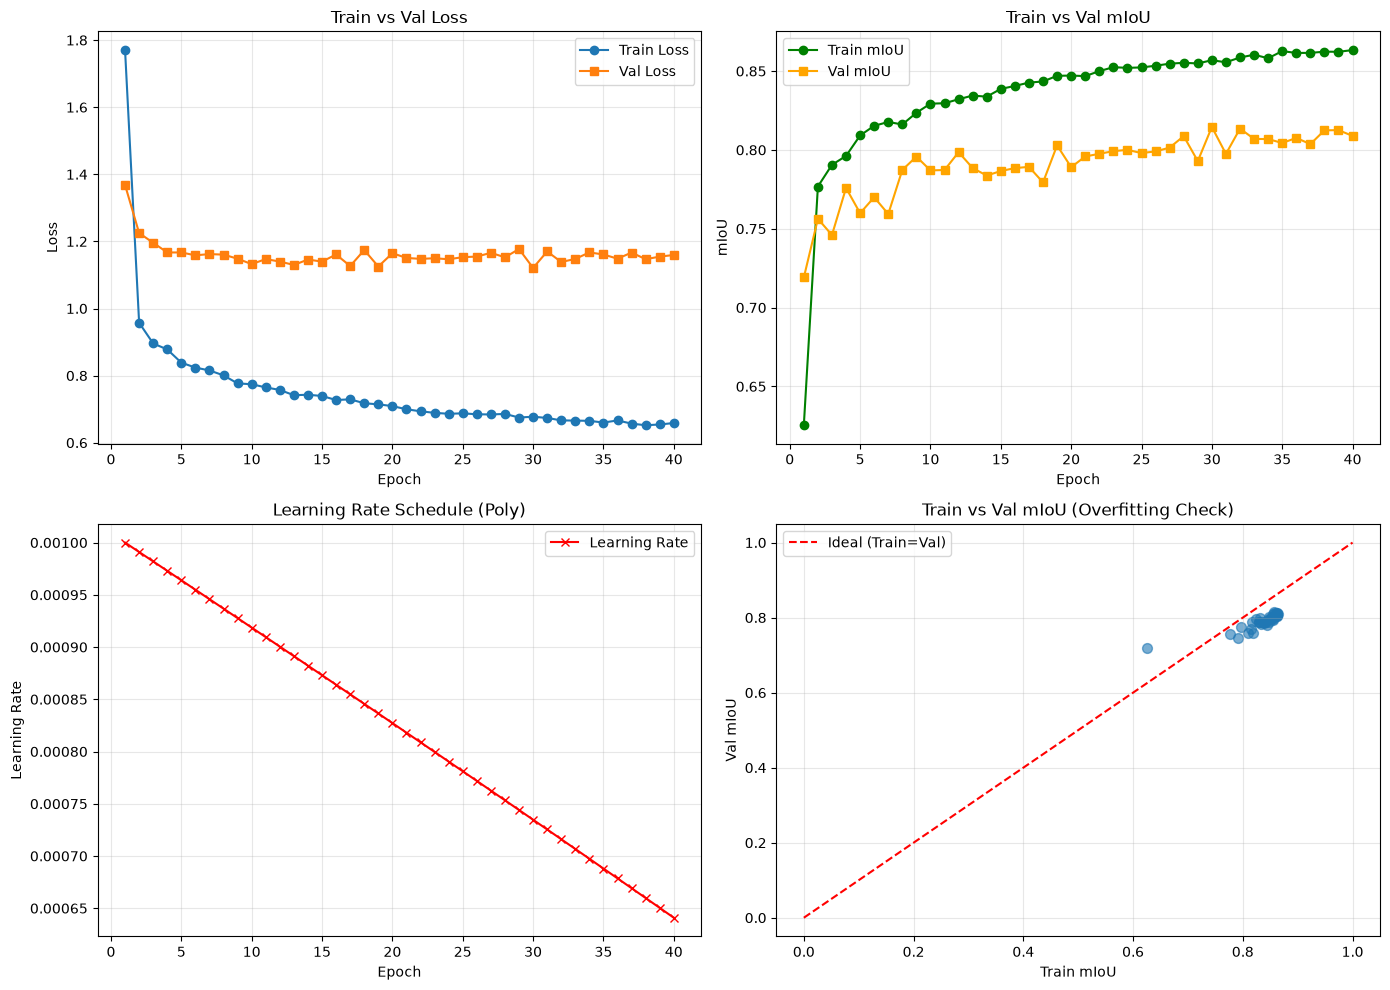


 RESUMEN FINAL:
Mejor Val mIoU: 0.8146 (Epoch 30)
Loss final (val): 1.1596


In [ ]:
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
fig1, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(epochs_range, history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Train vs Val Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# mIoU
fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.plot(epochs_range, history['train_miou'], label='Train mIoU', color='green')
ax2.plot(epochs_range, history['val_miou'], label='Val mIoU', color='orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('mIoU')
ax2.set_title('Train vs Val mIoU')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparación Train-Val mIoU (scatter)
fig3, ax3 = plt.subplots(figsize=(7, 5))
ax3.scatter(history['train_miou'], history['val_miou'], alpha=0.6, s=50)
ax3.plot([0, 1], [0, 1], 'r--', label='Ideal (Train=Val)')
ax3.set_xlabel('Train mIoU')
ax3.set_ylabel('Val mIoU')
ax3.set_title('Train vs Val mIoU (Overfitting Check)')
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

# Resumen final
print(f"\n RESUMEN FINAL:")
print(f"Mejor Val mIoU: {max(history['val_miou']):.4f} (Epoch {history['val_miou'].index(max(history['val_miou'])) + 1})")
print(f"Loss final (val): {history['val_loss'][-1]:.4f}")


Modelo cargado - Epoch 29 | Val mIoU: 0.8146


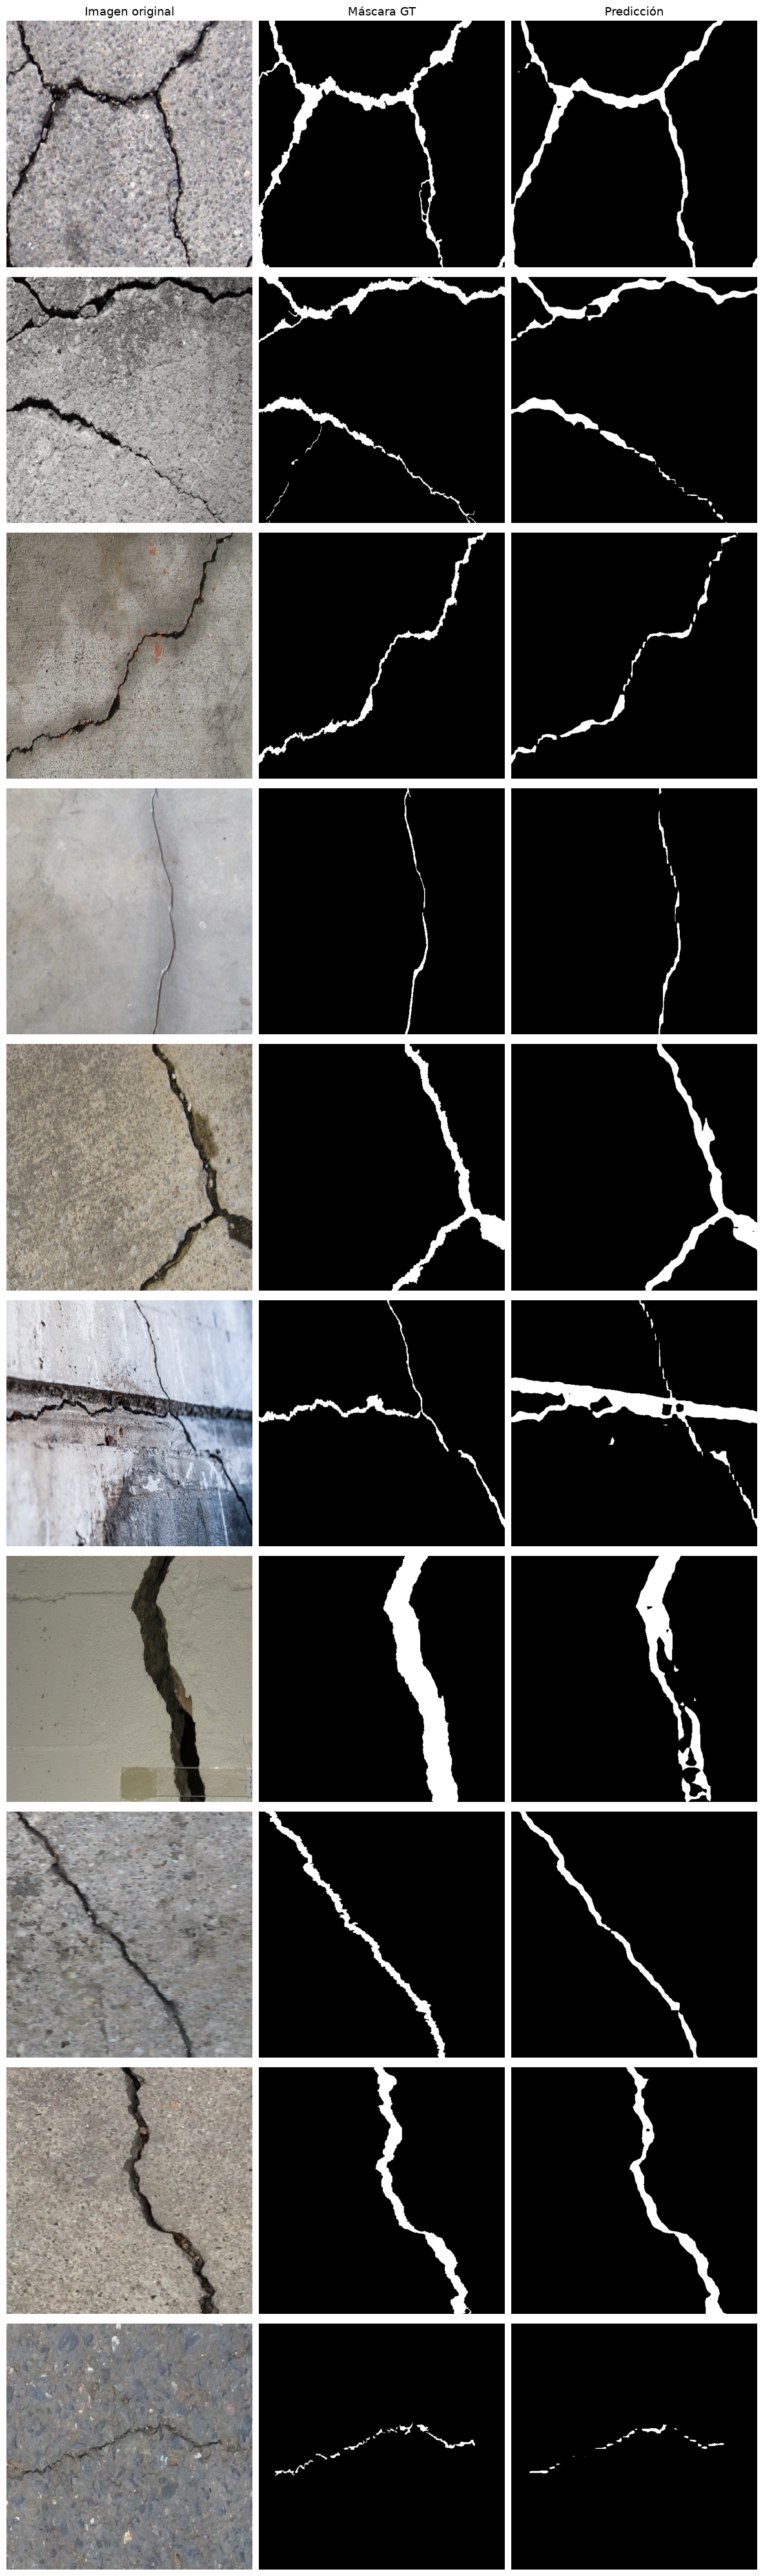

Se segmentaron 10 en 1.361383 segundos


In [ ]:
import random
import time

# ─── Configuración ────────────────────────────────────────────────────────────
CHECKPOINT_PATH = 'best_pidnet_S.pth'
NUM_IMAGES      = 10   # Cuántas imágenes del val set querés comparar

# ─── Cargar modelo desde checkpoint ───────────────────────────────────────────
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Modelo cargado - Epoch {checkpoint['epoch']} | Val mIoU: {checkpoint['val_miou']:.4f}")

# ─── Seleccionar imágenes aleatorias del val set ───────────────────────────────
indices = random.sample(range(len(val_dataset)), NUM_IMAGES)

fig, axes = plt.subplots(NUM_IMAGES, 3, figsize=(12, 4 * NUM_IMAGES))
axes[0, 0].set_title('Imagen original',  fontsize=13)
axes[0, 1].set_title('Máscara GT',       fontsize=13)
axes[0, 2].set_title('Predicción',       fontsize=13)

start = time.perf_counter()
with torch.no_grad():
    for row, idx in enumerate(indices):
        image, mask, _ = val_dataset[idx]          # Tensores ya normalizados

        # Forward pass
        input_tensor = image.unsqueeze(0).to(device)          # [1, C, H, W]
        outputs      = model(input_tensor)
        pred_final   = outputs[1]                              # Salida principal

        h, w       = mask.shape[0], mask.shape[1]
        pred_final = F.interpolate(pred_final, size=(h, w), mode='bilinear', align_corners=True)
        pred_mask  = pred_final.argmax(dim=1).squeeze(0).cpu().numpy()  # [H, W]

        # Convertir imagen a numpy para visualizar (des-normalizar si hace falta)
        img_np = image.permute(1, 2, 0).cpu().numpy()  # [H, W, 3]
        img_np = (img_np * 255).clip(0, 255).astype(np.uint8)

        # Plot
        axes[row, 0].imshow(img_np)
        axes[row, 1].imshow(mask.numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row, 2].imshow(pred_mask,    cmap='gray', vmin=0, vmax=1)

        # IoU de esta imagen
        tp    = ((pred_mask == 1) & (mask.numpy() == 1)).sum()
        fp    = ((pred_mask == 1) & (mask.numpy() == 0)).sum()
        fn    = ((pred_mask == 0) & (mask.numpy() == 1)).sum()
        denom = tp + fp + fn
        iou   = tp / denom if denom > 0 else 0.0
        axes[row, 2].set_xlabel(f'IoU grieta: {iou:.3f}', fontsize=11)

        for ax in axes[row]:
            ax.axis('off')

end = time.perf_counter()
plt.tight_layout()
plt.show()

elapsed = end - start
print(f"Se segmentaron {NUM_IMAGES} en {elapsed:.6f} segundos")


In [ ]:
# ─── Configuración ────────────────────────────────────────────────────────────
CHECKPOINT_PATH = 'best_pidnet_S.pth'
VIDEO_PATH      = r'..\..\datasets\videos\video_cracks_2.mp4'
OUTPUT_PATH     = r'..\..\datasets\videos\video_cracks_2_pred.mp4'

INPUT_SIZE      = (384, 544)              # (H, W) -> debe coincidir con el tamaño usado al entrenar
MEAN            = [0.485, 0.456, 0.406]   # Normalización ImageNet consistente con entrenamiento
STD             = [0.229, 0.224, 0.225]   # Normalización ImageNet consistente con entrenamiento

ALPHA           = 0.5    # transparencia del overlay (0 = invisible, 1 = opaco)
SHOW_LIVE       = True   # mostrar ventana mientras procesa (poné False si corrés en servidor/notebook headless)

# ─── Cargar modelo desde checkpoint (asume que `model` y `device` ya existen) ─
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Modelo cargado - Epoch {checkpoint['epoch']} | Val mIoU: {checkpoint['val_miou']:.4f}")

mean_t = torch.tensor(MEAN).view(3, 1, 1).to(device)
std_t  = torch.tensor(STD).view(3, 1, 1).to(device)


def preprocess(frame_bgr):
    """Frame BGR (OpenCV) -> tensor normalizado [1, C, H, W] en el tamaño de entrada del modelo."""
    frame_rgb     = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    frame_resized = cv2.resize(frame_rgb, (INPUT_SIZE[1], INPUT_SIZE[0]))
    tensor        = torch.from_numpy(frame_resized).permute(2, 0, 1).float().to(device) / 255.0
    tensor        = (tensor - mean_t) / std_t
    return tensor.unsqueeze(0)


def overlay_mask(frame_bgr, mask, color=(0, 0, 255)):
    """Superpone en rojo la máscara binaria (grieta=1) sobre el frame original."""
    overlay = frame_bgr.copy()
    overlay[mask == 1] = color
    return cv2.addWeighted(overlay, ALPHA, frame_bgr, 1 - ALPHA, 0)


# ─── Procesar video ────────────────────────────────────────────────────────────
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise IOError(f"No se pudo abrir el video: {VIDEO_PATH}")

fps_in   = cap.get(cv2.CAP_PROP_FPS)
w        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h        = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps_in, (w, h))

frame_count    = 0
inference_time = 0.0
t_start        = time.perf_counter()

with torch.no_grad():
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        input_tensor = preprocess(frame)

        t0         = time.perf_counter()
        outputs    = model(input_tensor)
        pred_final = outputs[1]                                     # salida principal (igual que en tu script de imágenes)
        pred_final = F.interpolate(pred_final, size=(h, w), mode='bilinear', align_corners=True)
        pred_mask  = pred_final.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
        inference_time += time.perf_counter() - t0

        frame_out = overlay_mask(frame, pred_mask)

        cv2.putText(frame_out, f'Frame {frame_count + 1}/{n_frames}', (10, 25),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

        writer.write(frame_out)
        if SHOW_LIVE:
            cv2.imshow('Segmentacion de grietas', frame_out)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

        frame_count += 1

t_end = time.perf_counter()
cap.release()
writer.release()
cv2.destroyAllWindows()

total_time = t_end - t_start
print(f"\nProcesados {frame_count} frames en {total_time:.2f} s")
print(f"FPS pipeline completo (lectura + preproc + inferencia + overlay + escritura): {frame_count / total_time:.2f}")
print(f"FPS solo inferencia (forward pass):                                          {frame_count / inference_time:.2f}")
print(f"Video guardado en: {OUTPUT_PATH}")

Modelo cargado - Epoch 29 | Val mIoU: 0.8146

Procesados 307 frames en 33.62 s
FPS pipeline completo (lectura + preproc + inferencia + overlay + escritura): 9.13
FPS solo inferencia (forward pass):                                          10.79
Video guardado en: ..\..\datasets\videos\video_cracks_2_pred.mp4
